In [91]:
import numpy as np
import scipy as sp
from scipy.special import hankel1
from numpy import pi, sqrt, exp, linspace, zeros
import matplotlib.pyplot as plt

### The function below gives one contribution to a Green's function sum, $4\pi k^2 a^3\sum_{n, m}\mathbf{G}(\mathbf{r}_{n, m}, \mathbf{0})$ for the case of a square lattice (where $n$ indexes the position along $x$ and $m$ indexes the position along $y$. The quantity returned is unitless and depends only on the ratio $\lambda/a$ (and of course the integers $n$ and $m$).

In [11]:
# We define lambda  in units of a 
def one_term(n, m, lambda_):
    cos_sqrd = n**2/(n**2+m**2)
    sin_sqrd = 1-cos_sqrd
    kr = (2*pi/lambda_)*sqrt(n**2+m**2)
    denom = (n**2+m**2)**(3/2)
    num = (kr**2)*sin_sqrd + (3*cos_sqrd - 1) * (1-1j*kr)
    return (num/denom)*exp(1j*kr)

In [78]:
M = 20
lambda_v = linspace(1.01, 1.06, M)
dipole_sums = zeros(M)
N = 8000
for (sum_idx, lambda_) in enumerate(lambda_v):
    print("sum_idx: ", sum_idx)
    dipole_sum = 0 
    for n in range(0, N+1):
        for m in range(0, N+1):
            if n == 0 and m == 0:
                continue
            if n==0 or m == 0: 
                dipole_sum += 2*one_term(n, m, lambda_) # multiply by 4 or 2 to take in to account n->-n, m->-m
            else: 
                dipole_sum += 4*one_term(n, m, lambda_) # multiply by 4 or 2 to take in to account n->-n, m->-m
    dipole_sums[sum_idx] = dipole_sum.real 

sum_idx:  0
sum_idx:  1
sum_idx:  2
sum_idx:  3
sum_idx:  4
sum_idx:  5
sum_idx:  6
sum_idx:  7
sum_idx:  8
sum_idx:  9
sum_idx:  10
sum_idx:  11
sum_idx:  12
sum_idx:  13
sum_idx:  14
sum_idx:  15
sum_idx:  16
sum_idx:  17
sum_idx:  18
sum_idx:  19


### The plot below should resemble Figure 6 (a) in the paper [Colloquium: Light scattering by particle and hole arrays](https://journals.aps.org/rmp/pdf/10.1103/RevModPhys.79.1267)

In [79]:
def dipole_sum_asymptotic(lambda_):
    return 4*pi**2*sqrt(2)*(1/sqrt(lambda_-1))-118

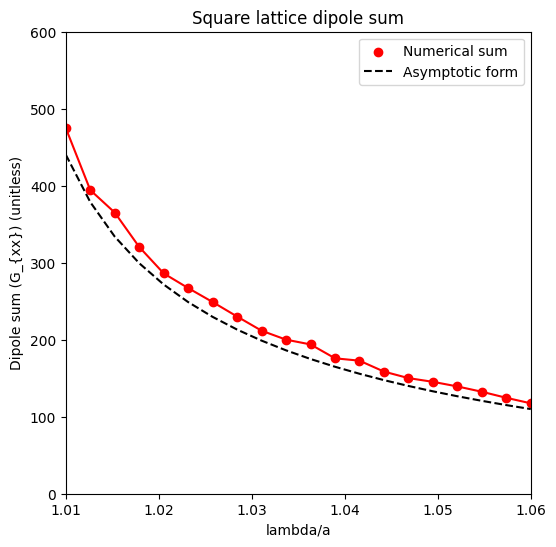

In [213]:
fig, ax = plt.subplots(figsize=(6, 6))
lambda_v = linspace(1.01, 1.06, M)
ax.scatter(lambda_v, dipole_sums, color="red", label="Numerical sum")
ax.plot(lambda_v, dipole_sums, color="red")

ax.plot(lambda_v, dipole_sum_asymptotic(lambda_v), linestyle="dashed", color="black", label="Asymptotic form")
ax.set_xlabel("lambda/a")
ax.set_ylim(0, 600)
ax.set_xlim(1.01, 1.06);
ax.set_ylabel("Dipole sum (G_{xx}) (unitless)");
ax.set_title("Square lattice dipole sum");
ax.legend();

### We now move on to the cylindrical case, with electric field along the cylinder axis. 

In [102]:
# We define lambda  in units of a 
def one_term_cylinder(n, lambda_):
    kr = (2*pi/lambda_)*n
    coeff = 1j*(pi/lambda_)**2
    return coeff * hankel1(0, kr)

In [188]:
M = 20
lambda_v = linspace(1.00001, 1.0001, M)
dipole_sums_cylinder = zeros(M)
N = 40000000
for (sum_idx, lambda_) in enumerate(lambda_v):
    print("sum_idx: ", sum_idx)
    dipole_sum = 0 
    for n in range(1, N+1):
        dipole_sum += 2*one_term_cylinder(n, lambda_) # multiply by 2 to take in to account n->-n
    dipole_sums_cylinder[sum_idx] = dipole_sum.real 

sum_idx:  0
sum_idx:  1
sum_idx:  2
sum_idx:  3
sum_idx:  4
sum_idx:  5
sum_idx:  6
sum_idx:  7
sum_idx:  8
sum_idx:  9
sum_idx:  10
sum_idx:  11
sum_idx:  12
sum_idx:  13
sum_idx:  14
sum_idx:  15
sum_idx:  16
sum_idx:  17
sum_idx:  18
sum_idx:  19


In [216]:
def dipole_sum_asymptotic_cylinder(lambda_):
    return 2*(pi)*1/sqrt(1-1/lambda_**2)

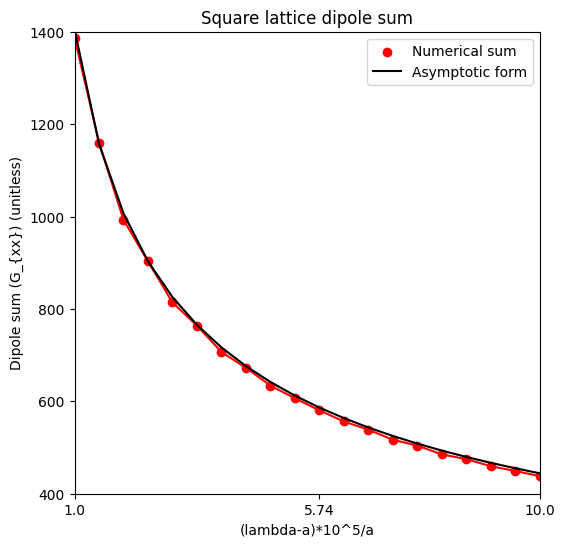

In [220]:
fig, ax = plt.subplots(figsize=(6, 6))
lambda_v = linspace(1.00001, 1.0001, M)
ax.scatter(lambda_v, dipole_sums_cylinder, color="red", label="Numerical sum")
ax.plot(lambda_v, dipole_sums_cylinder, color="red")
ax.plot(lambda_v, dipole_sum_asymptotic_cylinder(lambda_v), color="black", label="Asymptotic form")
ax.set_ylabel("Dipole sum (G_{xx}) (unitless)");
ax.set_xlabel("(lambda-a)*10^5/a")
ax.set_xticks(lambda_v[[0, 10, 19]], ((lambda_v[[0, 10, 19]]-1)*100000).round(2))
ax.set_title("Square lattice dipole sum");
ax.legend();
ax.set_xlim(lambda_v.min(), lambda_v.max());
ax.set_ylim(400, 1400);